In [184]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [185]:
df = pd.read_csv(
    "../data/processed/featured_superstore.csv",
    parse_dates=["Order Date", "Ship Date"]
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Discount,Profit,Year,Month,Month Name,Quarter,Day Name,Shipping Days,Profit Margin,Discount Category
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,41.9136,2016,11,November,4,Tuesday,3,16.00,No Discount
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,219.5820,2016,11,November,4,Tuesday,3,30.00,No Discount
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.00,6.8714,2016,6,June,2,Sunday,4,47.00,No Discount
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.45,-383.0310,2015,10,October,4,Sunday,7,-40.00,Medium Discount
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.20,2.5164,2015,10,October,4,Sunday,7,11.25,Low Discount


# Customers Analysis
🎯 Objective

Business ye samajhna chahta hai:

Kaunse customers sabse valuable hain?
Kis segment se sabse zyada revenue aata hai?
Kis state aur city me customers zyada hain?
Loyal customers kaun hain?

# Total Customers (KPI)
How many unique customers are there?

In [186]:
total_customers = df["Customer Name"].nunique()
print("Total Customers:", total_customers)

Total Customers: 793


## Business Question

How many unique customers are there?

## Why is this important?

- It helps understand the size of the customer base.
- It serves as a key business KPI.
- It is useful for measuring customer growth over time.
- It supports customer retention and acquisition analysis.

# 2. Top 10 Customers by Sales
Which customers generated the highest sales?


In [187]:
top_customers  = (df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10).reset_index())
top_customers 

,Customer Name,Sales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


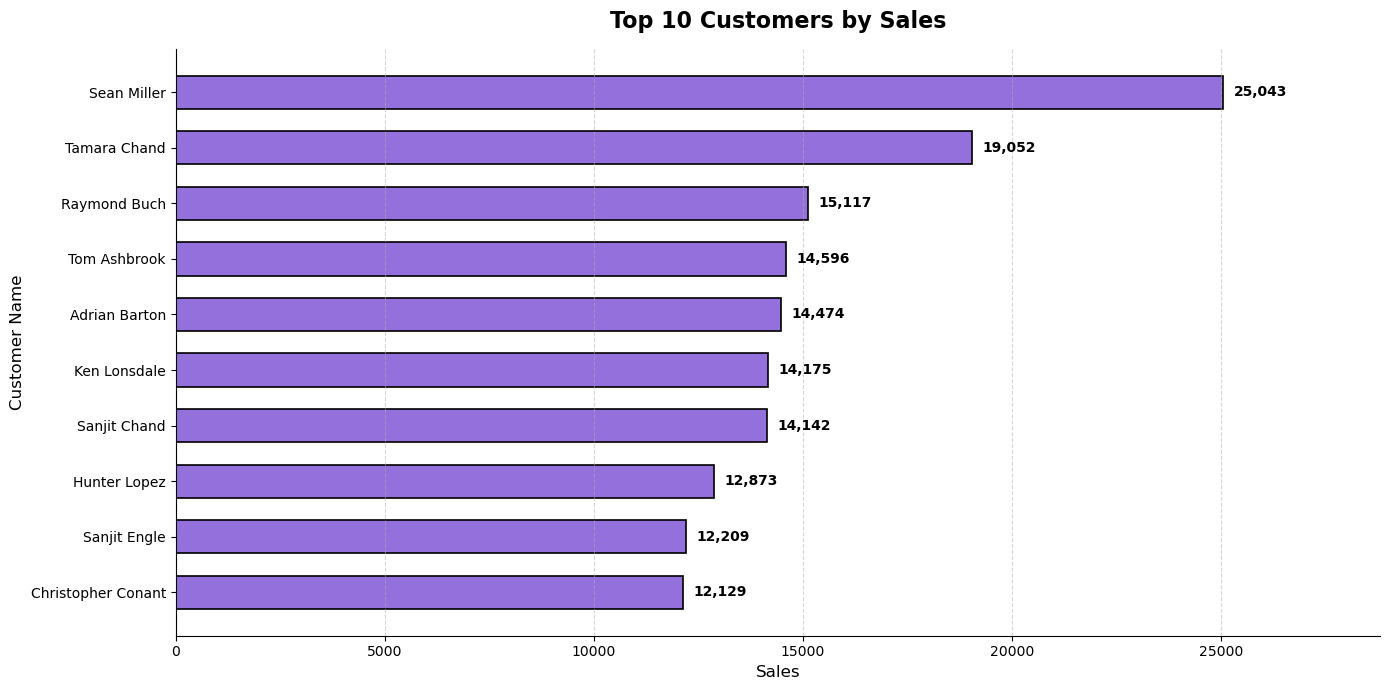

In [188]:

plt.figure(figsize=(14,7))

bars = plt.barh(top_customers["Customer Name"], top_customers["Sales"],
         color="mediumpurple", edgecolor="black",
         linewidth=1.2, height=0.6)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Sales", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Sales", fontsize=12)

plt.ylabel("Customer Name", fontsize=12)

plt.grid(axis="x",linestyle="--", alpha=0.5)
plt.yticks(fontsize=10)

plt.xlim(0, top_customers["Sales"].max() * 1.15)

# Value labels
offset = top_customers["Sales"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="left",
        fontsize=10, fontweight="bold"
    )


plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/top10_customers_sales.png",dpi=300, bbox_inches="tight"
)
plt.show()



Top 10 Customers by Sales

# Objective

Identify the customers contributing the highest sales.

# Business Value

Identify VIP customers.
Improve customer retention.
Design loyalty programs.
Increase repeat purchases.
Focus marketing on high-value customers.

# Visualization

# Horizontal Bar Chart

# Key Insight

Sean Miller is the highest revenue-generating customer, followed by Tamara Chand. These customers represent the business's most valuable customer segment and should be prioritized for retention strategies.

# Top 10 Customers by Profit
Which customers generated the highest profit?

In [189]:
top_customers_by_profit = (df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False).head(10).reset_index())
top_customers_by_profit

,Customer Name,Profit
0,Tamara Chand,8981.3239
1,Raymond Buch,6976.0959
2,Sanjit Chand,5757.4119
3,Hunter Lopez,5622.4292
4,Adrian Barton,5444.8055
5,Tom Ashbrook,4703.7883
6,Christopher Martinez,3899.8904
7,Keith Dawkins,3038.6254
8,Andy Reiter,2884.6208
9,Daniel Raglin,2869.0760


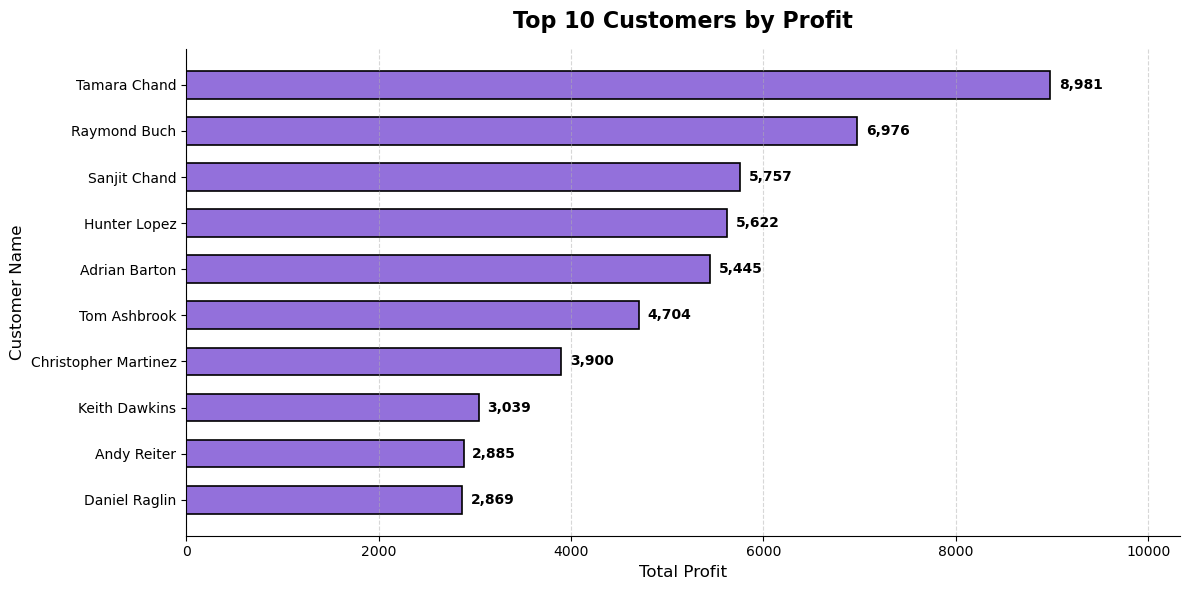

In [190]:
plt.figure(figsize=(12,6))

bars = plt.barh(top_customers_by_profit["Customer Name"], top_customers_by_profit["Profit"], color="mediumpurple", edgecolor="black", linewidth=1.2, height=0.6)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Profit", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Profit", fontsize=12)

plt.ylabel("Customer Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlim(0, top_customers_by_profit["Profit"].max() * 1.15)


offset = top_customers_by_profit["Profit"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="left",
        fontsize=10, fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/top10_customers_profit.png",dpi=300, bbox_inches="tight"
)


plt.show()

# Top 10 Loss-Making Customers
Which customers generated the highest loss?

In [191]:
top10_loss_customers = (df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=True).head(10).reset_index())
top10_loss_customers

,Customer Name,Profit
0,Cindy Stewart,-6626.3895
1,Grant Thornton,-4108.6589
2,Luke Foster,-3583.9770
3,Sharelle Roach,-3333.9144
4,Henry Goldwyn,-2797.9635
5,Nathan Cano,-2204.8072
6,Sean Braxton,-2082.7451
7,Sean Miller,-1980.7393
8,Christine Phan,-1850.3029
9,Natalie Fritzler,-1695.9714


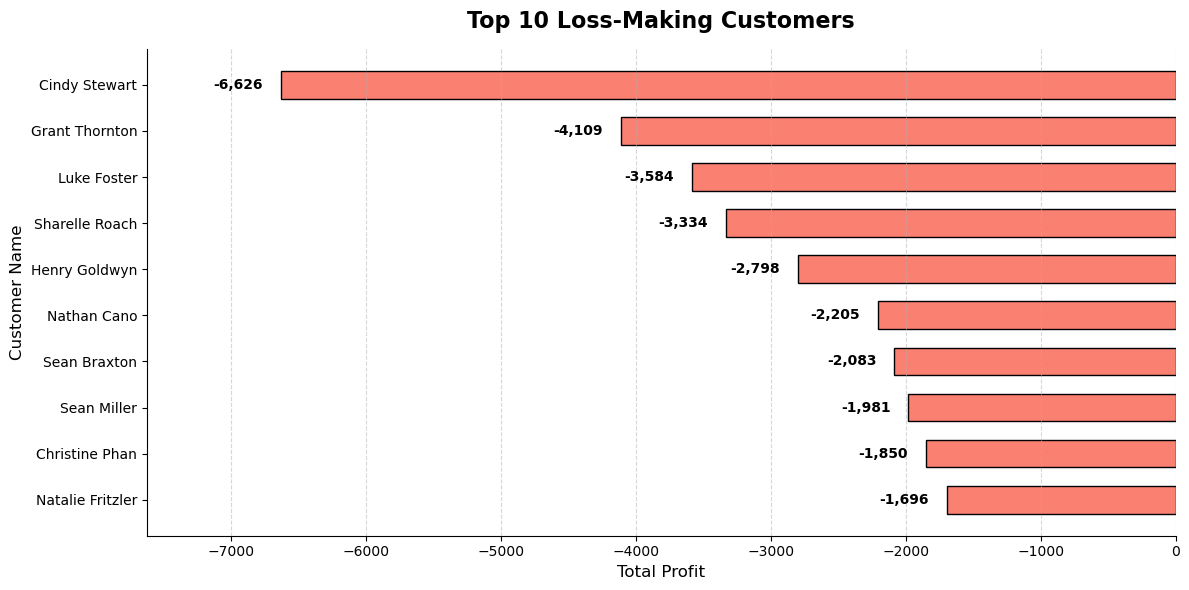

In [192]:
plt.figure(figsize=(12,6))

bars = plt.barh(top10_loss_customers["Customer Name"], top10_loss_customers["Profit"],
         color="salmon",
         
         edgecolor="black",
         height=0.6)

plt.gca().invert_yaxis()

plt.title("Top 10 Loss-Making Customers", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Profit", fontsize=12)
plt.ylabel("Customer Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Extra Space for labels
plt.xlim(top10_loss_customers["Profit"].min() * 1.15,0)

offset = abs(top10_loss_customers["Profit"].min()) * 0.02

for bar in bars:
    plt.text(
        bar.get_width() - offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="right",
        fontsize=10,
        fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/top10_loss_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Sales by Customer Segment
Which customer segment generated the highest sales?

In [193]:
segment_sales  = (df.groupby("Segment")["Sales"].sum().reset_index())
segment_sales 

,Segment,Sales
0,Consumer,1.161401e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


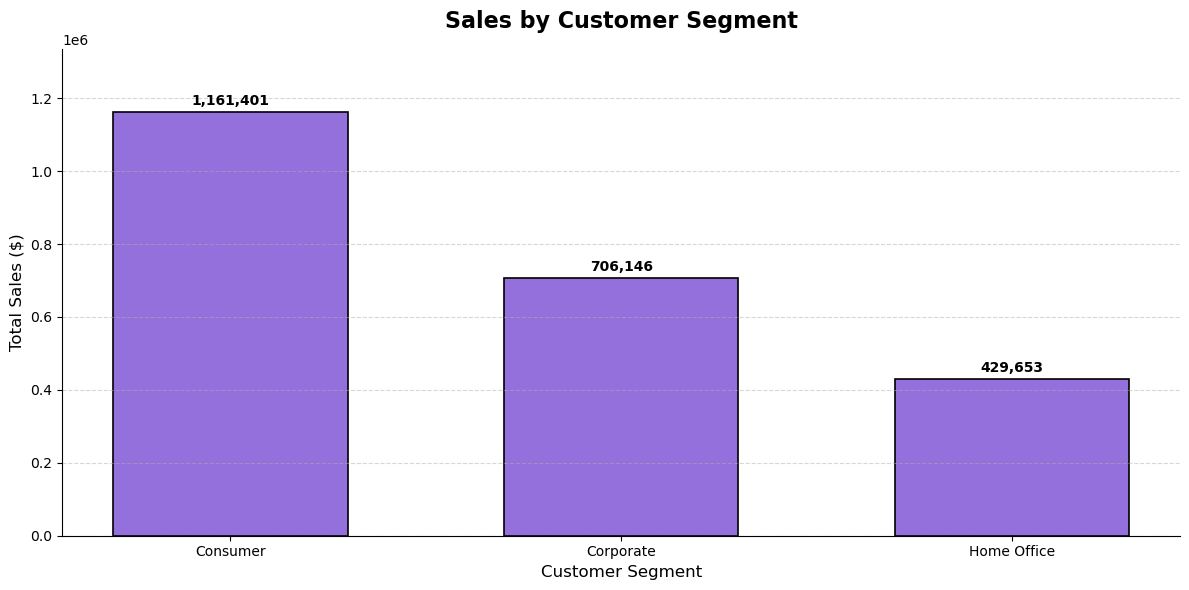

In [194]:
plt.figure(figsize=(12,6))

bars = plt.bar(segment_sales["Segment"], segment_sales["Sales"],
               color="mediumpurple",
               edgecolor="black",
               linewidth=1.2,
               width=0.6
)

plt.title("Sales by Customer Segment",
          fontsize=16,
          fontweight="bold",
          pad=15
)

plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.ylim(0, segment_sales["Sales"].max() * 1.15)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

offset = segment_sales["Sales"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + offset,
        f"{bar.get_height():,.0f}",
        va="bottom",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/customer_segment_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Profit by Customer Segment
Which customer segment generated the highest profit?

In [195]:
segment_profit = (df.groupby("Segment")["Profit"].sum().sort_values(ascending=False).reset_index())
segment_profit

,Segment,Profit
0,Consumer,134119.2092
1,Corporate,91979.1340
2,Home Office,60298.6785


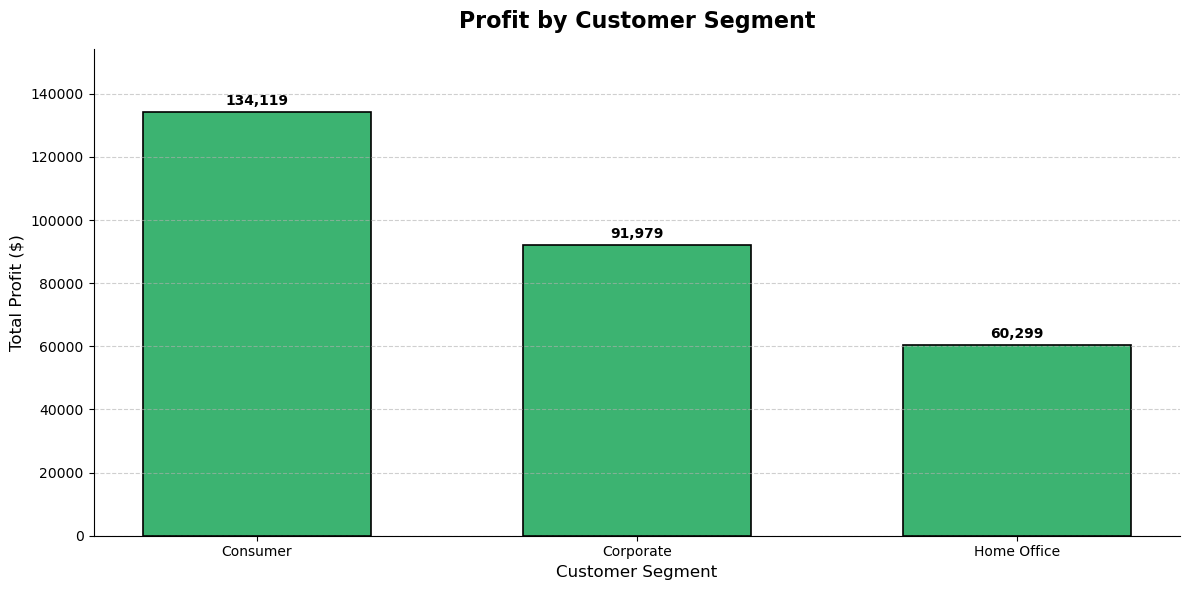

In [196]:
plt.figure(figsize=(12,6))

bars = plt.bar(segment_profit["Segment"], segment_profit["Profit"],
        color="mediumseagreen", edgecolor="black", linewidth=1.2, width=0.6)

plt.title("Profit by Customer Segment", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Total Profit ($)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.ylim(0, segment_profit["Profit"].max() * 1.15)

offset = segment_profit["Profit"].max() * 0.01

for bar in bars:
        plt.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + offset,
                f"{bar.get_height():,.0f}",
                ha="center", va="bottom",
                fontsize=10, fontweight="bold"
        )
        
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
        "../visualizations/customers/customer_segment_profits.png",
        dpi=300, 
        bbox_inches="tight"
)

plt.show()

# Customer Distribution by Segment
How are customers distributed across different segments?

In [197]:
customer_distribution = (
    df.groupby("Segment")["Customer Name"].nunique().reset_index(name="Customer Count")
)
customer_distribution

,Segment,Customer Count
0,Consumer,409
1,Corporate,236
2,Home Office,148


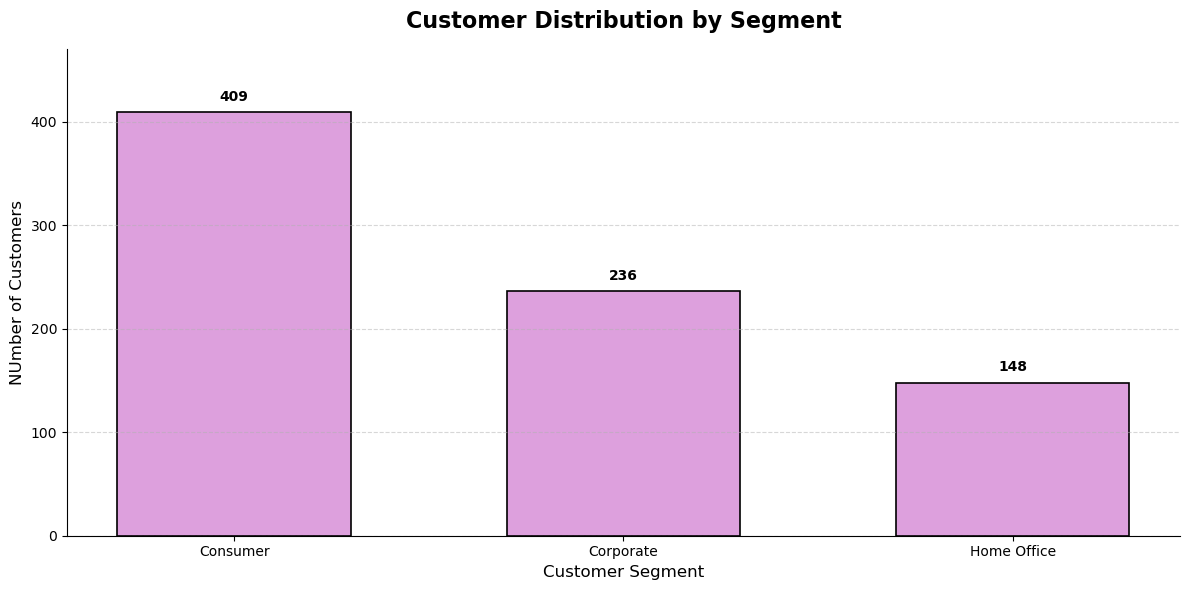

In [198]:
plt.figure(figsize=(12,6))

bars = plt.bar(customer_distribution["Segment"], customer_distribution["Customer Count"],
               color="plum", edgecolor="black", linewidth=1.2, width=0.6)

plt.title("Customer Distribution by Segment", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("NUmber of Customers", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.ylim(0, customer_distribution["Customer Count"].max() * 1.15)

offset = customer_distribution["Customer Count"].max() * 0.02

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + offset,
        f"{bar.get_height():,.0f}",
        va="bottom", ha="center",
        fontsize=10, fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/customer_distribution_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Average Sales per Customer
What is the average sales generated by each customer?

In [199]:
avg_sales_customer = (df.groupby("Customer Name")["Sales"].mean().sort_values(ascending=False).head(10).reset_index())
avg_sales_customer

,Customer Name,Sales
0,Mitch Willingham,1751.292000
1,Sean Miller,1669.536667
2,Tamara Chand,1587.684833
3,Grant Thornton,1558.535333
4,Tom Ashbrook,1459.562000
5,Hunter Lopez,1170.299818
6,Bill Shonely,1166.850333
7,Christopher Conant,1102.642909
8,Stefanie Holloman,1048.196000
9,Christopher Martinez,895.402000


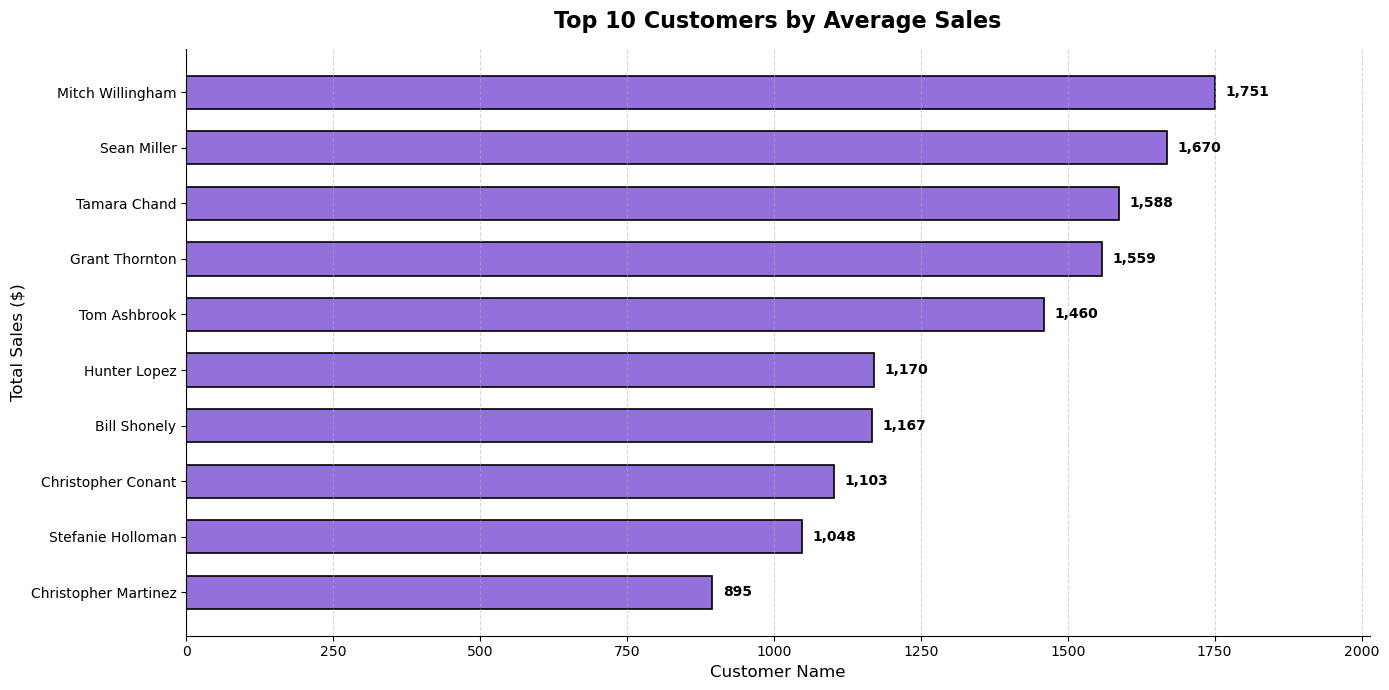

In [200]:
plt.figure(figsize=(14,7))

bars = plt.barh(avg_sales_customer["Customer Name"], avg_sales_customer["Sales"],
         color="mediumpurple", edgecolor="black", linewidth=1.2, height=0.6)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Average Sales", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Customer Name", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.yticks(fontsize=10)

plt.xlim(0, avg_sales_customer["Sales"].max() * 1.15)

offset = avg_sales_customer["Sales"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/average_sales_per_customer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Average Profit per Customer
Which customers generate the highest average profit?

In [201]:
avg_profit_customer = (df.groupby("Customer Name")["Profit"].mean().sort_values(ascending=False).head(10).reset_index())
avg_profit_customer

,Customer Name,Profit
0,Tamara Chand,748.443658
1,Mitch Willingham,555.172000
2,Hunter Lopez,511.129927
3,Tom Ashbrook,470.378830
4,Christopher Martinez,389.989040
5,Raymond Buch,387.560883
6,Andy Reiter,320.513422
7,Bill Shonely,290.673822
8,Adrian Barton,272.240275
9,Sanjit Chand,261.700541


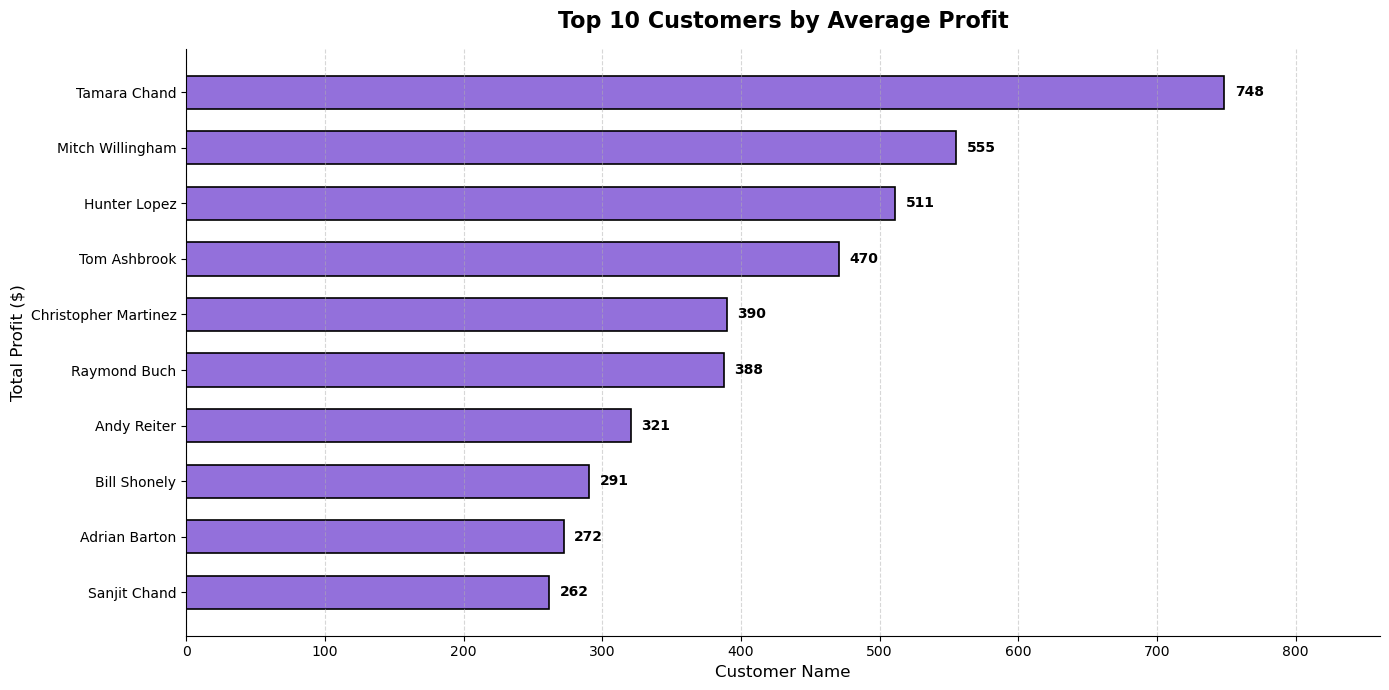

In [202]:
plt.figure(figsize=(14,7))

bars = plt.barh(avg_profit_customer["Customer Name"], avg_profit_customer["Profit"],
         color="mediumpurple", edgecolor="black", linewidth=1.2, height=0.6)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Average Profit", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Customer Name", fontsize=12)
plt.ylabel("Total Profit ($)", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.yticks(fontsize=10)

plt.xlim(0, avg_profit_customer["Profit"].max() * 1.15)

offset = avg_profit_customer["Profit"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/average_profit_per_customer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Repeat Customers
Which customers placed the most orders?

In [203]:
repeat_customers = (df.groupby("Customer Name")["Order ID"].nunique().sort_values(ascending=False).head(10).reset_index(name="Number of Orders"))
repeat_customers

,Customer Name,Number of Orders
0,Emily Phan,17
1,Sally Hughsby,13
2,Noel Staavos,13
3,Patrick Gardner,13
4,Zuschuss Carroll,13
5,Joel Eaton,13
6,Erin Ashbrook,13
7,Chloris Kastensmidt,13
8,Suzanne McNair,12
9,Rick Bensley,12


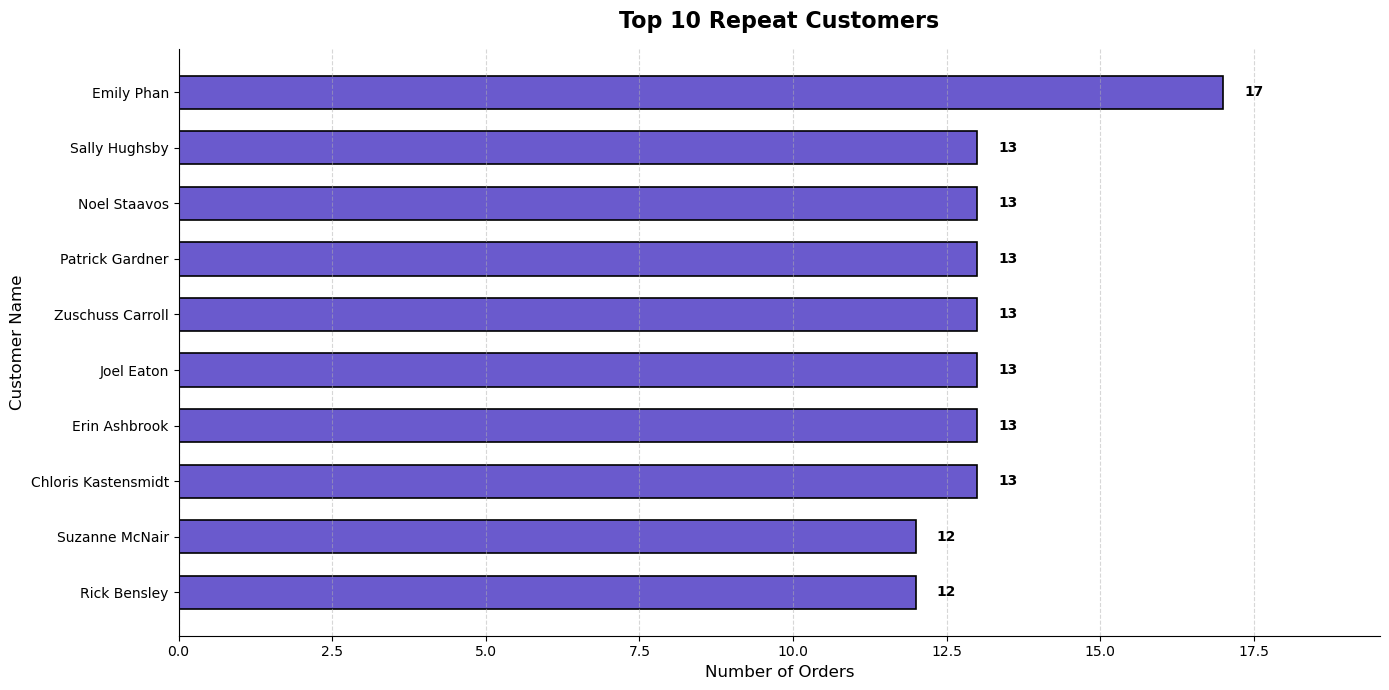

In [204]:
plt.figure(figsize=(14,7))

bars = plt.barh(
    repeat_customers["Customer Name"],
    repeat_customers["Number of Orders"],
    color="slateblue",
    edgecolor="black",
    linewidth=1.2,
    height=0.6
)

# Highest orders at top
plt.gca().invert_yaxis()

plt.title(
    "Top 10 Repeat Customers",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Orders", fontsize=12)

plt.ylabel("Customer Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.yticks(fontsize=10)

plt.xlim(0, repeat_customers["Number of Orders"].max() * 1.15)

offset = repeat_customers["Number of Orders"].max() * 0.02

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width())}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/repeat_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# Customer Lifetime Value (CLV)
Which customers generated the highest lifetime value?

In [212]:
customer_clv = (
    df.groupby("Customer Name")
    .agg(
        Total_Sales = ("Sales", "sum"),
        Total_Profit = ("Profit", "sum")
    )
    .reset_index()
)


customer_clv["CLV"] = (customer_clv["Total_Sales"] + customer_clv["Total_Profit"])


# Top 10 Customers
customer_clv = (customer_clv.sort_values("CLV", ascending=False).head())
customer_clv

,Customer Name,Total_Sales,Total_Profit,CLV
730,Tamara Chand,19052.218,8981.3239,28033.5419
686,Sean Miller,25043.050,-1980.7393,23062.3107
622,Raymond Buch,15117.339,6976.0959,22093.4349
6,Adrian Barton,14473.571,5444.8055,19918.3765
671,Sanjit Chand,14142.334,5757.4119,19899.7459


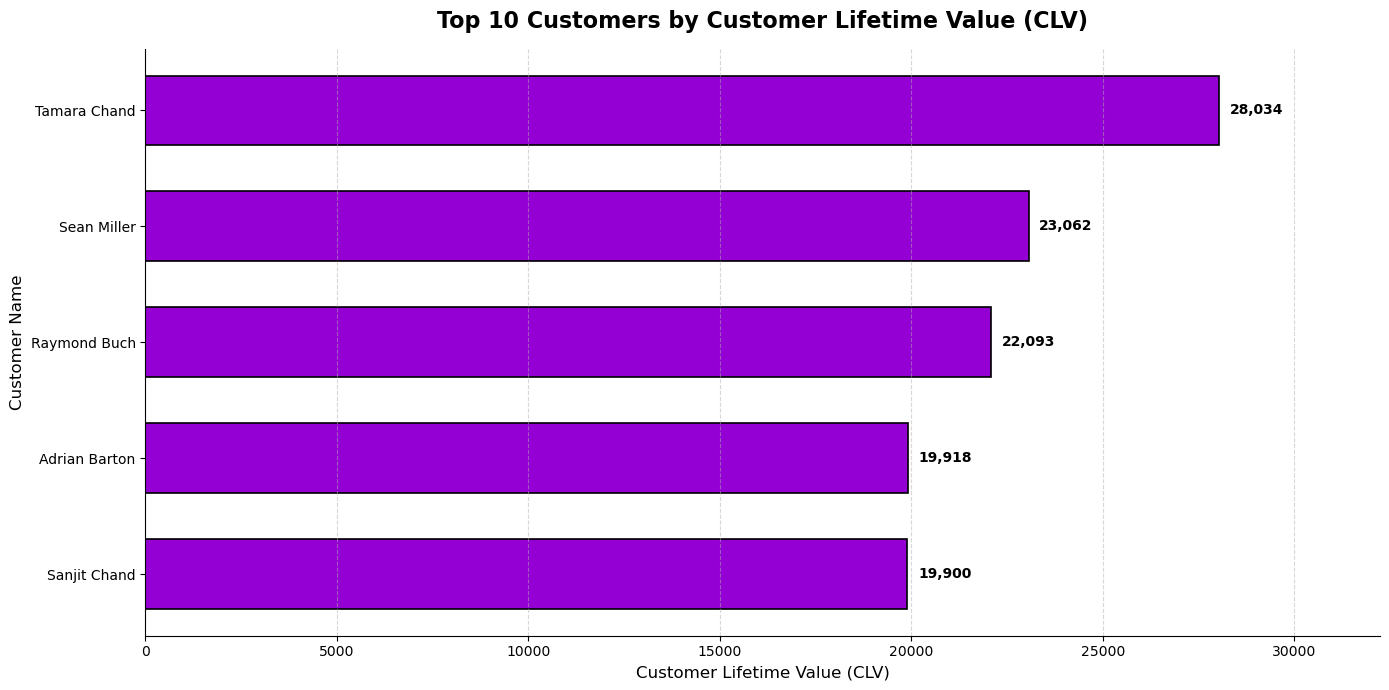

In [213]:
plt.figure(figsize=(14,7))

bars = plt.barh(
    customer_clv["Customer Name"],
    customer_clv["CLV"],
    color="darkviolet",
    edgecolor="black",
    linewidth=1.2,
    height=0.6
)

# Highest CLV at top
plt.gca().invert_yaxis()

plt.title(
    "Top 10 Customers by Customer Lifetime Value (CLV)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Customer Lifetime Value (CLV)", fontsize=12)

plt.ylabel("Customer Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlim(0, customer_clv["CLV"].max() * 1.15)

offset = customer_clv["CLV"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/customer_lifetime_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Customer Order Frequency
How frequently do customers place orders?

In [217]:
customer_order_frequency = (df.groupby("Customer Name")["Order ID"].nunique().reset_index(name="Number of Orders"))
customer_order_frequency

,Customer Name,Number of Orders
0,Aaron Bergman,3
1,Aaron Hawkins,7
2,Aaron Smayling,7
3,Adam Bellavance,8
4,Adam Hart,10
...,...,...
788,Xylona Preis,11
789,Yana Sorensen,8
790,Yoseph Carroll,5
791,Zuschuss Carroll,13


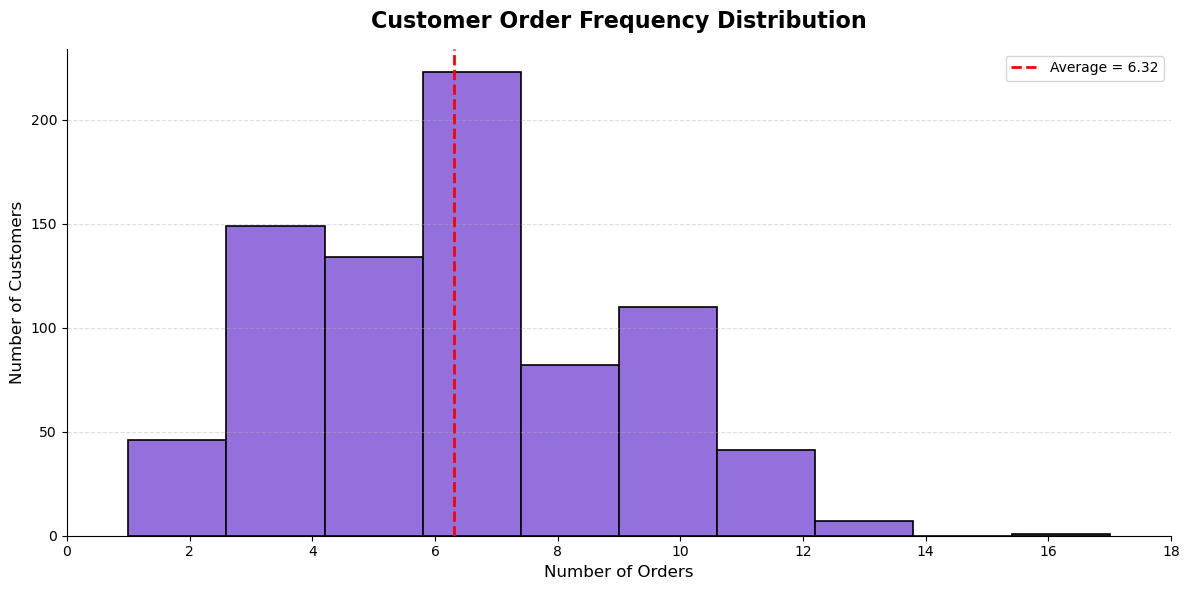

In [238]:
plt.figure(figsize=(12,6), dpi=100)

plt.hist(customer_order_frequency["Number of Orders"],
         bins=10, color="mediumpurple", edgecolor="black", linewidth=1.2)

plt.title("Customer Order Frequency Distribution",
          fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Number of Orders", fontsize=12)

plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.xlim(
    0,
    customer_order_frequency["Number of Orders"].max() + 1
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

mean_orders = customer_order_frequency["Number of Orders"].mean()

plt.axvline(
    mean_orders,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Average = {mean_orders:.2f}"
)

plt.legend()

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/customer_order_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Customer Sales vs Profit
Do customers with higher sales always generate higher profits?

In [246]:
customer_sales_profit  = (df.groupby("Customer Name").agg(
    Total_Sales = ("Sales", "sum"),
    Total_Profit = ("Profit", "sum")
).reset_index()
)
customer_sales_profit.head()


,Customer Name,Total_Sales,Total_Profit
0,Aaron Bergman,886.156,129.3465
1,Aaron Hawkins,1744.700,365.2152
2,Aaron Smayling,3050.692,-253.5746
3,Adam Bellavance,7755.620,2054.5885
4,Adam Hart,3250.337,281.1890


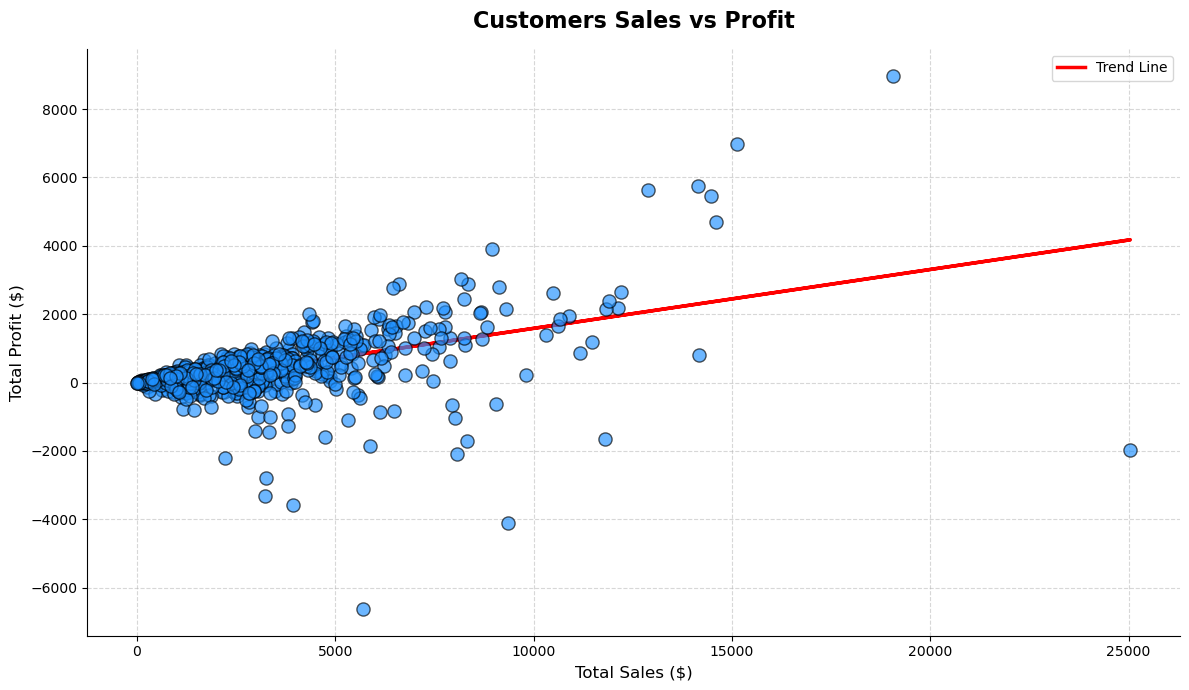

In [268]:
plt.figure(figsize=(12,7))
plt.scatter(customer_sales_profit["Total_Sales"],
            customer_sales_profit["Total_Profit"],
            color="dodgerblue",
            edgecolor="black",
            alpha=0.65,
            s=90,
            zorder=3
)

plt.title("Customers Sales vs Profit", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Sales ($)", fontsize=12)

plt.ylabel("Total Profit ($)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

z = np.polyfit(
    customer_sales_profit["Total_Sales"],
    customer_sales_profit["Total_Profit"],
    1
)

p = np.poly1d(z)

plt.plot(
    customer_sales_profit["Total_Sales"],
    p(customer_sales_profit["Total_Sales"]),
    color="red",
    linewidth=2.5,
    label="Trend Line"
)

plt.ticklabel_format(style="plain")

plt.legend()

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
     "../visualizations/customers/customer_sales_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Insights

- Consumer segment generated the highest sales.
- A small group of customers contributed significantly to total revenue.
- Some customers generated high sales but relatively low profit.
- Most customers placed only a few orders.
- Repeat customers form the loyal customer base.

# Business Recommendations

- Retain high-value customers through loyalty programs.
- Improve profitability for high-sales but low-profit customers.
- Encourage one-time buyers to become repeat customers.
- Focus marketing on profitable customer segments.